In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import datetime

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Proyecto/Players.xlsx'

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Proyecto/Players.xlsx', header=0)

In [ ]:
print(df.columns)

Index(['Player', 'Pos', 'Squad', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s',
       'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'Gls/90',
       'Ast/90', 'G+A/90', 'G-PK/90', 'G+A-PK/90'],
      dtype='object')


In [ ]:
cols = [
    "Player",
    "Squad",
    "Age",
    "Min",
    "Gls",
    "Ast",
    "G+A",
    "Gls/90",
    "Ast/90",
    "G+A/90"
]

df = df[cols]

In [ ]:
df["Offensive Score"] = (
    df["G+A/90"] * 0.50 +
    df["Ast/90"] * 0.30 +
    df["Gls/90"] * 0.20
)

In [ ]:
df = df.sort_values("Offensive Score", ascending=False)

In [ ]:
df["Rank"] = range(1, len(df) + 1)

In [ ]:
df.to_excel("midfield_offensive_ranking.xlsx", index=False)

print("Archivo creado: midfield_offensive_ranking.xlsx")
print(df[["Rank", "Player", "Squad", "Offensive Score"]])

Archivo creado: midfield_offensive_ranking.xlsx
   Rank           Player            Squad  Offensive Score
7     1     Fermín López        Barcelona            0.570
6     2      Arda Güller      Real Madrid            0.446
9     3            Pedri        Barcelona            0.367
2     4  Jude Bellingham      Real Madrid            0.348
3     5   Santi Comesaña       Villarreal            0.258
4     6       Samu Costa         Mallorca            0.217
0     7  Mauro Arambarri           Getafe            0.162
8     8     Ilaix Moriba       Celta Vigo            0.137
5     9      Aleix Febas            Elche            0.085
1    10    Pablo Barrios  Atlético Madrid            0.080


In [ ]:
df.to_excel("midfield_offensive_ranking.xlsx", index=False)

In [ ]:
from google.colab import files

files.download("midfield_offensive_ranking.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

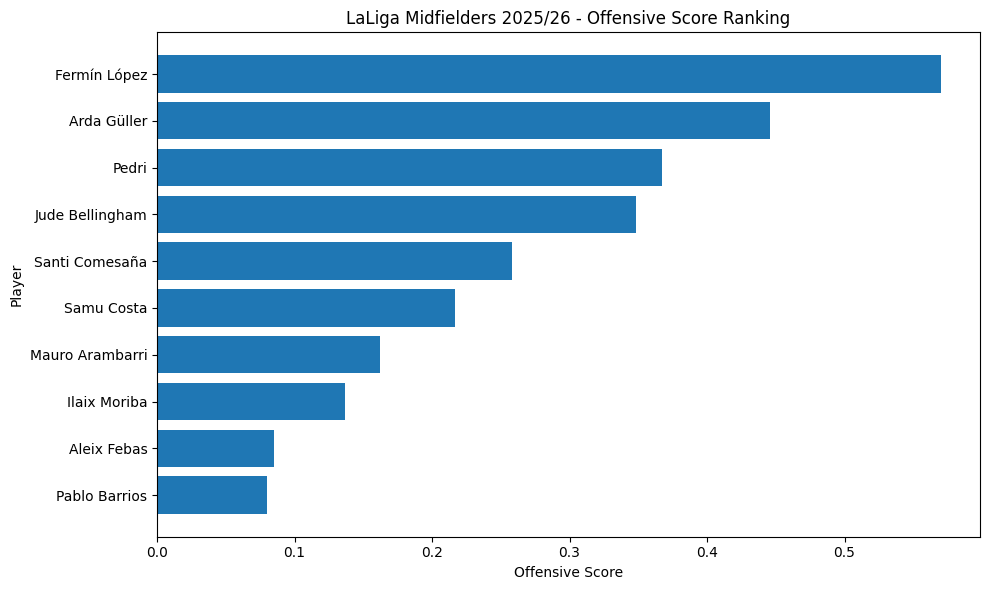

In [ ]:
top10 = df.sort_values("Offensive Score", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(top10["Player"], top10["Offensive Score"])
plt.xlabel("Offensive Score")
plt.ylabel("Player")
plt.title("LaLiga Midfielders 2025/26 - Offensive Score Ranking")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
team_colors = {
    "Getafe": "#003B7A",           # Azul oscuro
    "Atlético Madrid": "#CB3524", # Rojo
    "Real Madrid": "#FFFFFF",     # Blanco
    "Villarreal": "#FFF200",      # Amarillo
    "Mallorca": "#E30613",        # Rojo
    "Elche": "#00843D",           # Verde
    "Barcelona": "#A50044",       # Granate
    "Celta Vigo": "#7DB7E8"       # Celeste
}

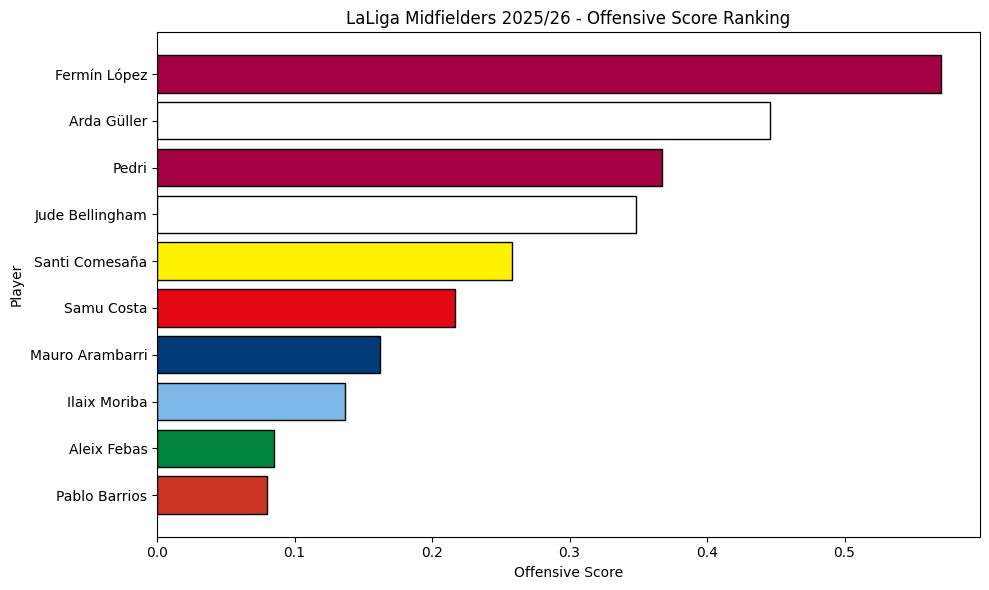

In [ ]:
colors = [team_colors.get(team, "#808080") for team in top10["Squad"]]

plt.figure(figsize=(10,6))

plt.barh(
    top10["Player"],
    top10["Offensive Score"],
    color=colors,
    edgecolor="black"
)

plt.xlabel("Offensive Score")
plt.ylabel("Player")
plt.title("LaLiga Midfielders 2025/26 - Offensive Score Ranking")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

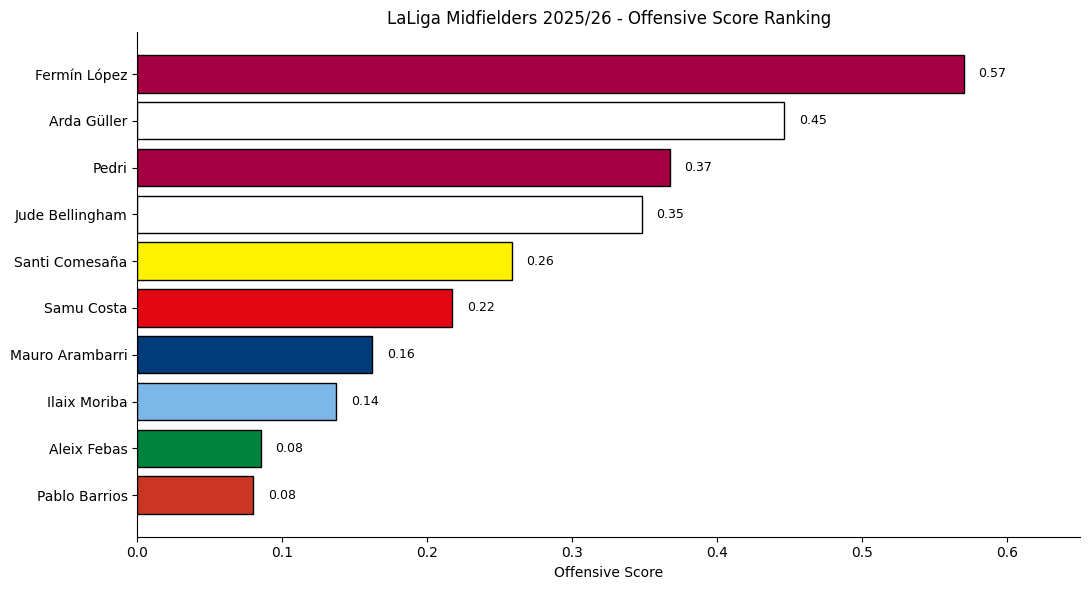

In [ ]:
import matplotlib.pyplot as plt

top10 = df.sort_values("Offensive Score", ascending=False)

team_colors = {
    "Getafe": "#003B7A",
    "Atlético Madrid": "#CB3524",
    "Real Madrid": "#FFFFFF",
    "Villarreal": "#FFF200",
    "Mallorca": "#E30613",
    "Elche": "#00843D",
    "Barcelona": "#A50044",
    "Celta Vigo": "#7DB7E8"
}

colors = [team_colors.get(team, "#808080") for team in top10["Squad"]]

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top10["Player"],
    top10["Offensive Score"],
    color=colors,
    edgecolor="black",
    linewidth=1
)

plt.xlabel("Offensive Score")
plt.title("LaLiga Midfielders 2025/26 - Offensive Score Ranking")
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=9
    )

plt.xlim(0, top10["Offensive Score"].max() + 0.08)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("offensive_score_ranking.png", dpi=300, bbox_inches="tight")
plt.show()